**Final Project: Data Science Pipeline Tutorial** <br>
**Alcohol's Effect on Academic Performance**<br>
**Benjamin Yi, Arno Babcock, and Petr Tsypnyatov**<br>

For our final project, we decided to focus on data containing key information on student alcohol consumption, which we found on data.world. In this tutorial, we will be showing you the various steps of the Data Science Pipeline, and how you can analyze and use whatever data you might be interested in. These steps can be broken down into the following:
Data collection/curation + parsing (if necessary),
Data management/representation,
Exploratory data analysis,
Hypothesis testing and machine learning, and
Communication of insights attained.
<br>
There are a few things that we will need to do to get set up. <br>
1. You will need an IDE to be able to run and test your code. We will be using Jupyter Notebook for this project, and recommend you do the same as it also functions as a presentation tool.<br>
2. Once you have an IDE installed, you can create a new file and begin writing your code.<br>
3. For this particular project, we are going to use a few Python libraries, which we will have listed here.<br>
-pandas: used for its DataFrame features<br>
-numpy: used for plotting lines of best fit<br>
-matplotlib: used to create different visuals for data visualization<br>
-sklearn: used for machine learning and linear regression<br>
-statsmodels: use for linera regression summary <br>
4. Once you have all this set up, we can begin with the first step: collecting and parsing the data.<br>

# Data collection/curation + parsing (if necessary)

The first step of the Data Science Pipeline is finding the data you want to analyze. In our case, we want to take a look at the statistics for student alcohol consumption, which can be found here: https://data.world/data-society/student-alcohol-consumption, and we are given a dataset as a .csv file. There is more information on what each of the variables mean on the website. There are many ways for you to collect, or "scrape" your data, it can be on a website, in a table, or as an excel file. Since our data is in the form of a .csv file, we will use the pandas library to read it. We can use the read_csv() method from the pandas library to create a DataFrame object from a .csv file. A dataframe is a 2-dimensional labeled structure with columns that can have different types, which is perfect for what we need. We create the DataFrame, and assign it to a variable table, and then display table.

Note: What goes in parentheses is actually the path to the file that we want to read data from. Since we have the .csv file in the same folder as this project, we can just write the filename, otherwise you would need to add the entire file path before the name of the file.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from statsmodels.formula.api import ols


data = pd.read_csv("student-mat.csv")
data

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


Now that we have the data as a DataFrame object, we can begin the next step which is managing and representing our data.

# Data management/representation

When we take a look at our data, there are a lot of columns containing variables that we are not really interested in. Some of the variables that we will not need include school, address, reason, guardian, travel time, schoolsup, famsup, paid, activity, nursery, higher, internet, and romantic. The pandas library provides us with some easy methods to use to drop these columns from the dataframe. 

In [45]:
data = data.drop(['school', 'address', 'reason', 'guardian', 'traveltime', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic'], axis=1)
data

,sex,age,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,F,18,GT3,A,4,4,at_home,teacher,2,0,4,3,4,1,1,3,6,5,6,6
1,F,17,GT3,T,1,1,at_home,other,2,0,5,3,3,1,1,3,4,5,5,6
2,F,15,LE3,T,1,1,at_home,other,2,3,4,3,2,2,3,3,10,7,8,10
3,F,15,GT3,T,4,2,health,services,3,0,3,2,2,1,1,5,2,15,14,15
4,F,16,GT3,T,3,3,other,other,2,0,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,M,20,LE3,A,2,2,services,services,2,2,5,5,4,4,5,4,11,9,9,9
391,M,17,LE3,T,3,1,services,services,1,0,2,4,5,3,4,2,3,14,16,16
392,M,21,GT3,T,1,1,other,other,1,3,5,5,3,3,3,3,3,10,8,7
393,M,18,LE3,T,3,2,services,other,1,0,4,4,1,3,4,5,0,11,12,10


Now we have a much tidier dataset to look at. We can further simplify the DataFrame by looking at the grade columns G1, G2, and G3. These refer to the grades a student received in the first semester, second semester, and their final grade. For the purpose of our project, we can add these scores up and instead of having 3 separate columns, we can create one column to hold each student's grade score. We can do the same thing for drinking and add the Dalc, which represents how much a student drinks during the week, and Walc, which represents how much a student drinks during the weekend.

In [46]:
data['grade_score'] = data['G1'] + data['G2'] + data['G3']
data = data.drop(['G1', 'G2', 'G3'], axis = 1)
data['drink_score'] = data['Dalc'] + data['Walc']
data

,sex,age,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,grade_score,drink_score
0,F,18,GT3,A,4,4,at_home,teacher,2,0,4,3,4,1,1,3,6,17,2
1,F,17,GT3,T,1,1,at_home,other,2,0,5,3,3,1,1,3,4,16,2
2,F,15,LE3,T,1,1,at_home,other,2,3,4,3,2,2,3,3,10,25,5
3,F,15,GT3,T,4,2,health,services,3,0,3,2,2,1,1,5,2,44,2
4,F,16,GT3,T,3,3,other,other,2,0,4,3,2,1,2,5,4,26,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,M,20,LE3,A,2,2,services,services,2,2,5,5,4,4,5,4,11,27,9
391,M,17,LE3,T,3,1,services,services,1,0,2,4,5,3,4,2,3,46,7
392,M,21,GT3,T,1,1,other,other,1,3,5,5,3,3,3,3,3,25,6
393,M,18,LE3,T,3,2,services,other,1,0,4,4,1,3,4,5,0,33,7


Now that is our data is in the form that we want it, we can start to analyze these numbers to come to a conclusion.

# Exploratory data analysis

Using the matplotlib library we can plot our data in the form of graphs which we can use to do all kinds of things, like detect trends in our data. The first thing that we can do is a simple bar graph, where we compare boy's alcohol consumption to girl's. 

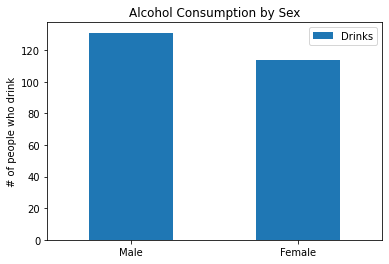

In [47]:
# Holds number of males and females that drink
female_drinks = 0
male_drinks = 0

# Iterate through each student and add whether they are a male/female and they drink
for index, row in data.iterrows():
    if row['sex'] == "F" and row['drink_score'] > 2:
        female_drinks += 1
    if row['sex'] == "M" and row['drink_score'] > 2:
        male_drinks += 1

# Create a dataframe that holds these two variables, and bar graph
df = pd.DataFrame({'Drinks': [male_drinks, female_drinks]}, index = ["Male", "Female"])
ax = df.plot.bar(rot=0)
plt.ylabel("# of people who drink")
plt.title("Alcohol Consumption by Sex")
plt.show()

Using the drink_score column, we classify any student as someone who drinks if they have a total drink_score over 2. This means that when they were asked about their alcohol consumption on a scale of 1-5, they answered greater than 1 for either their weekday or weekend drinking. We add up the number of males and females that drink, and then plot it as a bar graph using df.plot.bar. From the bar graph, we can see that there are a higher number of male students that drink than females. If we want to go more in-depth with this, we can determine how often each gender drinks on the weekdays and weekends and make a double bar graph.

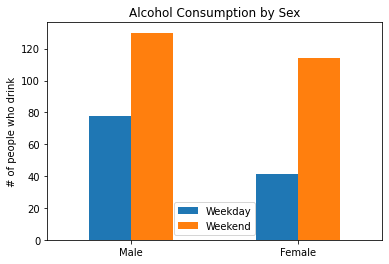

In [53]:
#Setting variables to create dataframe entries
d_alcB= 0
w_alcB = 0

d_alcF = 0
w_alcF = 0

cur_D = 0
cur_W = 0;

#Grouping by sex and counting if a person drinks
for t in data.groupby("sex"):
    for index, row in t[1].iterrows():
        #Values >= 2 mean that the person drinks
        if row['Walc'] >= 2:
            cur_W+=1
        if row['Dalc'] >= 2:
            cur_D+=1

    #If the bin is Female/Male set corisponding values
    if t[0] == "F":
        w_alcF = cur_W
        d_alcF = cur_D
    else:
        w_alcB = cur_W
        d_alcB = cur_D

    cur_W = 0
    cur_D = 0


#Create lists to insert into dataframe
d_alc = [d_alcB, d_alcF]
w_alc = [w_alcB, w_alcF]
index = ['Male','Female']

#Create dataframe and make bar graph
df = pd.DataFrame({'Weekday': d_alc,'Weekend': w_alc}, index=index)
ax = df.plot.bar(rot=0)
plt.ylabel("# of people who drink")
plt.title("Alcohol Consumption by Sex")
plt.show()

In this bar graph we use the same method of determining if a male or female student drinks, and then plot how many of them drink on weekdays and weekends. Next, we can start using scatter plots and lines of best fit to find any trends amongst our data. Off the top of our heads, we can assume that here will be a negative correlation between failures and grades, as students that tend to fail classes will typically have worse grades.

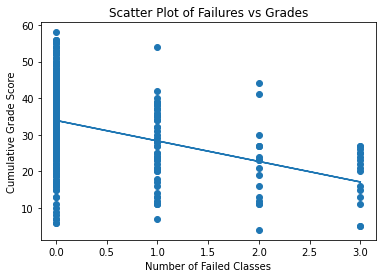

In [49]:
#Creates a line of best fit and a scatter plot of failed classes vs grades

m, b = np.polyfit(data['failures'],data['grade_score'], 1)
plt.plot(data['failures'],m*data['failures'] + b)
plt.scatter(x=data['failures'],y=data['grade_score'])
plt.xlabel("Number of Failed Classes")
plt.ylabel("Cumulative Grade Score")
plt.title("Scatter Plot of Failures vs Grades")


plt.show()

As shown in the scatterplot above, we found that as the number of failed classes increased for students, their cumulative grade scores decreased. This tells us that there is a negative correlation between the two variables. For our next graph, we can choose two variables that we think will have a positive correlation, like parent's education and grades.

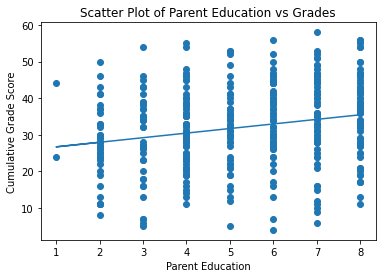

In [50]:
#Creates a new column called parent_edu which is a sum of parents education
data['parent_edu'] = 0;

for index, row in data.iterrows():
    data.at[index,'parent_edu'] = row['Medu']+ row['Fedu']

#Creates a line of best fit and a scatter plot of parent education vs grades


m, b = np.polyfit(data['parent_edu'],data['grade_score'], 1)
plt.plot(data['parent_edu'],m*data['parent_edu'] + b)
plt.scatter(x=data['parent_edu'],y=data['grade_score'])
plt.xlabel("Parent Education")
plt.ylabel("Cumulative Grade Score")
plt.title("Scatter Plot of Parent Education vs Grades")

plt.show()

From the scatterplot above, it is evident that there is indeed a positive correlation between cumulative grade scores and parent education. For the next step, we can do something a little more complicated using matplotlib.pyplot's violin plotting. First, we create a violinplot of the grade distribution vs weekday alcohol consumption levels. Then, we create another violinplot of the grade distribution vs weekend alcohol consumption levels. Then we can plot them together with a legend to see the different weekday drinking has on grades in addition to weekend drinking.

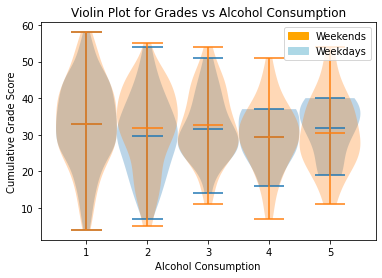

In [54]:
grade_per_weekday_alc = []
toAppend = []
drink_amt = []
#group by amount of weekday alcohol consumed and create fields
for t in data.groupby("Dalc"):
    drink_amt.append(t[0])
    for index, row in t[1].iterrows():
        toAppend.append(row['grade_score'])

    grade_per_weekday_alc.append(toAppend)
    toAppend = []


#Creates a violin plot of the amount of weekday alcohol consumed vs grades
plt.violinplot(grade_per_weekday_alc,drink_amt,widths=1,showmeans=True)


grade_per_weekend_alc = []
toAppend = []
drink_amt = []

#group by amount of weekend alcohol consumed and create fields
for t in data.groupby("Walc"):
    drink_amt.append(t[0])
    for index, row in t[1].iterrows():
        toAppend.append(row['grade_score'])

    grade_per_weekend_alc.append(toAppend)
    toAppend = []


#Creates a violin plot of the amount of weekend alcohol consumed vs grades
plt.violinplot(grade_per_weekend_alc,drink_amt,widths=1,showmeans=True)
plt.xlabel("Alcohol Consumption")
plt.ylabel("Cumulative Grade Score")
plt.title("Violin Plot for Grades vs Alcohol Consumption")
#Creates labels for the graph
red_patch = mpatches.Patch(color='orange', label='Weekends')
blue_patch = mpatches.Patch(color='lightblue', label='Weekdays')
plt.legend(handles=[red_patch, blue_patch])

plt.show()

As we can see from the plot above, people who responded with 1-3 receive relatively similar grades whether it be for the week or weekends. However, people who responded with a 4-5 on weekdays have signficantly worse grades than those who responded with a 4-5 on weekends. This makes sense because most students choose to do most of their work during the week, and use the weekend as free time.

# Hypothesis testing and machine learning

From the above graphs and data, it seems like increased drinking leads to a decrease in positive outcomes in general. We think it is safe to hypothesise that higher levels of drinking would also lead to lower grades. We will try proving this by using linear regression and machine learning to predict a line of best fit for a scatter plot that represents the data.

As drinking increases, Grades decrease by  [-0.50118302]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            grade_score   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.186
Date:                Mon, 17 May 2021   Prob (F-statistic):             0.0750
Time:                        16:00:12   Log-Likelihood:                -1508.8
No. Observations:                 395   AIC:                             3022.
Df Residuals:                     393   BIC:                             3030.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      33.9285      1.196     28.358      0.000      31.576      36.281
drink_score    -0.5012      0.281     -1.785      0.075      -1.053       0.051
==============================================================================
Omnibus:                        4.144   Durbin-Watson:                   2.024
Prob(Omnibus):                  0.126   Jarque-Bera (JB):                3.956
Skew:                          -0.195   Prob(JB):                        0.138
Kurtosis:                       2.704   Cond. No.                         9.56
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

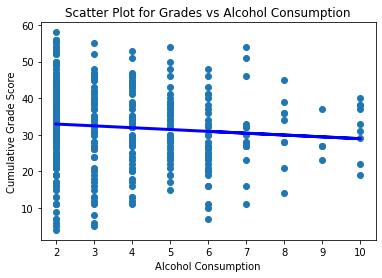

In [52]:
plt.scatter(x=data['drink_score'], y=data['grade_score'])
plt.xlabel("Alcohol Consumption")
plt.ylabel("Cumulative Grade Score")
plt.title("Scatter Plot for Grades vs Alcohol Consumption")

# We need to reshape the data and convert it to an arrray in order to pass it as a parameter

ds_reshaped = data['drink_score'].to_numpy().reshape(-1,1)

model = LinearRegression().fit(ds_reshaped,data['grade_score'])

# plotting and predicting the line of best fit

y_pred = model.predict(ds_reshaped)
plt.plot(data['drink_score'].to_numpy().reshape(-1,1), y_pred, color='blue', linewidth=3)

print("As drink score increases by 1, cumulative grade score decrease by ", model.coef_)
reg = ols('grade_score~drink_score', data=data).fit()
reg.summary()

# Communication of insights attained

From this tutorial, we learned about how to find, collect, analyze, visualize, and then interpret data. We started off with a dataset from a free online database, which we then imported into Jupyter Notebook. Using features from the pandas library, we cleaned up our data removing any uncessary information. We then learned how to plot different sets of our data to see if we could find any relationships or trends between variables. Finally, we tested to see if an increased level of drinking would lead to lower grades, which we then tested using linear regression.
<br>
With this information, you now have the ability to go and begin your own Data Science projects involving data scraping and analysis. **Good luck!**